In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "Data_Pertumbuhan_Ekonomi_Pulau_Kotor.csv",
    sep=";",
    encoding="latin1",
    on_bad_lines="skip"
)

display(df.columns)

display(df.head())

Index(['Laju Pertumbuhan dan Sumber Pertumbuhan PDRB Menurut Pulau (persen)',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6'],
      dtype='object')

,Laju Pertumbuhan dan Sumber Pertumbuhan PDRB Menurut Pulau (persen),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Pulau,Triw III-2025 terhadap Triw II-2025 (Q-to-Q)1,Triw IV-2025 terhadap Triw III-2025 (Q-to-Q)1,Triw III-2025 terhadap Triw III-2024 (Y-on-Y)2,Triw IV-2025 terhadap Triw IV-2024 (Y-on-Y)2,Laju Pertumbuhan 2025,Sumber Pertumbuhan 2025
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sumatera,"1,81","0,36","4,90","4,54","4,81","1,00"
3,Jawa,"0,78","1,86","5,17","5,80","5,30","3,11"
4,Bali dan Nusa Tenggara,"0,94","3,89","4,72","7,70","4,87","0,13"


In [13]:
df = df.iloc[2:, [0, 5]]

df.columns = ["Pulau", "Laju_Pertumbuhan_Ekonomi"]

df = df.dropna()
display(df.info())
df = df.reset_index(drop=True)

print(df)

df.to_csv(
    "pertumbuhan_ekonomi_per_pulau.csv",
    index=False
)

df.to_json(
    "pertumbuhan_ekonomi_per_pulau.json",
    orient="records",
    indent=4
)

print("File CSV dan JSON berhasil disimpan!")

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 2 to 7
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Pulau                     6 non-null      object
 1   Laju_Pertumbuhan_Ekonomi  6 non-null      object
dtypes: object(2)
memory usage: 144.0+ bytes


None

                    Pulau Laju_Pertumbuhan_Ekonomi
0                Sumatera                     4,81
1                    Jawa                     5,30
2  Bali dan Nusa Tenggara                     4,87
3              Kalimantan                     4,79
4                Sulawesi                     6,23
5        Maluku dan Papua                     1,44
File CSV dan JSON berhasil disimpan!


## EXPLORATORY DATA ANALYSIS

In [8]:
data = pd.read_csv('pertumbuhan_ekonomi_per_pulau.csv')
display(data)

,Pulau,Laju_Pertumbuhan_Ekonomi
0,Sumatera,"4,81"
1,Jawa,"5,30"
2,Bali dan Nusa Tenggara,"4,87"
3,Kalimantan,"4,79"
4,Sulawesi,"6,23"
5,Maluku dan Papua,"1,44"


In [23]:
print(data.describe())


       Laju_Pertumbuhan_Ekonomi
count                  6.000000
mean                   4.573333
std                    1.629806
min                    1.440000
25%                    4.795000
50%                    4.840000
75%                    5.192500
max                    6.230000


C:\Users\Adrian Alfarisi\AppData\Local\Temp\ipykernel_2824\541970959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Laju_Pertumbuhan_Ekonomi', y='Pulau', data=data_sorted, palette='viridis', ax=ax)


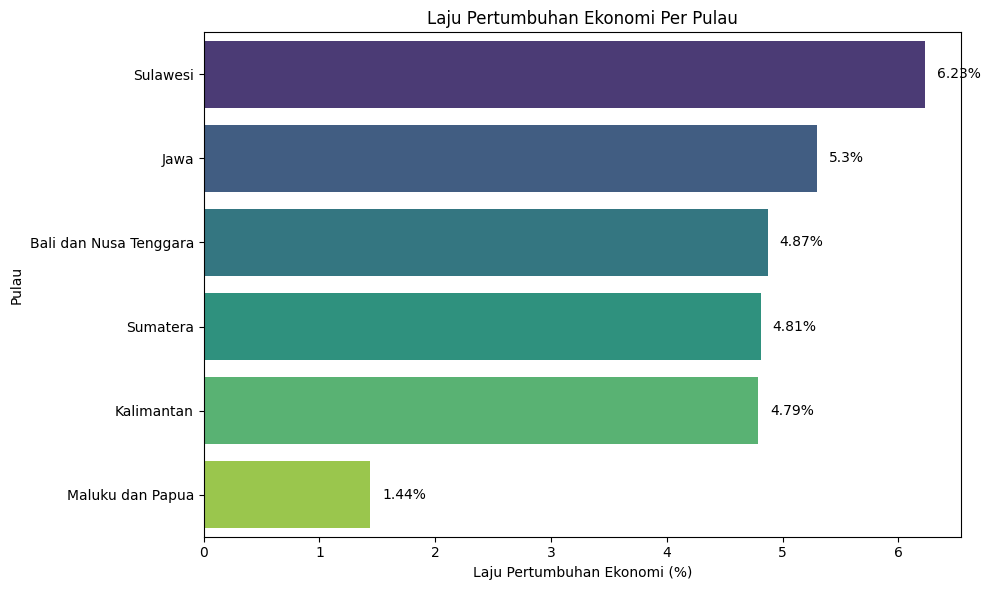

In [ ]:
data_terkecil = data.sort_values(by='Laju_Pertumbuhan_Ekonomi', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Laju_Pertumbuhan_Ekonomi', y='Pulau', data=data_sorted, palette='viridis', ax=ax)

for index, value in enumerate(data_terkecil['Laju_Pertumbuhan_Ekonomi']):
    ax.text(value + 0.1, index, f'{value}%', va='center')

ax.set_title('Laju Pertumbuhan Ekonomi Per Pulau')
ax.set_xlabel('Laju Pertumbuhan Ekonomi (%)')
ax.set_ylabel('Pulau')
plt.tight_layout()
plt.show()